## LOGISTIC REGRESSION 

In [20]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [21]:
class MyLogisticRegression:
    def __init__(self, lr=0.01, n_iters=1000):
        self.lr=lr
        self.n_iters=n_iters
        self.weights=None
        self.bias=None
        
    def _sigmoid(self, z):
        return 1/(1+np.exp(-z))
    
    def fit(self, X, y):
        n_samples, n_features=X.shape
        
        #Initialize parameters
        self.weights=np.zeros(n_features)
        self.bias=0
        
        #Gradient Descent
        for _ in range(self.n_iters):
            linear_model=np.dot(X, self.weights)+self.bias
            y_pred=self._sigmoid(linear_model)
            
            #gradients
            dw=(1/n_samples)*np.dot(X.T, (y_pred-y))
            db=(1/n_samples)*np.sum(y_pred-y)
            
            #Update
            self.weights-=self.lr*dw
            self.bias-=self.lr*db
            
    def predict_proba(self,X):
        linear_model=np.dot(X, self.weights) + self.bias 
        return self._sigmoid(linear_model)
    
    def predict(self,X):
        y_pred_probs=self.predict_proba(X)
        return (y_pred_probs>=0.5).astype(int)
    
    def score(self, X, y):
        y_pred=self.predict(X)
        return np.mean(y_pred==y)
    

In [22]:
# Load data
data=load_breast_cancer()
X,y=data.data, data.target #type:ignore


# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [23]:
#Scale
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [24]:
# Train
model = MyLogisticRegression(lr=0.01, n_iters=1000)
model.fit(X_train, y_train)

/var/folders/08/7cs_shf56lb78lkgpnm7z4bh0000gn/T/ipykernel_60257/1596196551.py:9: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-z))


In [25]:
# Evaluate
accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.9473684210526315


/var/folders/08/7cs_shf56lb78lkgpnm7z4bh0000gn/T/ipykernel_60257/1596196551.py:9: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-z))


In [26]:
import numpy as np

def confusion_matrix(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    return np.array([[tn, fp],
                     [fn, tp]])

In [27]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm):
    plt.imshow(cm)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.show()

In [28]:
def classification_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp = cm[0]
    fn, tp = cm[1]

    precision = tp / (tp + fp + 1e-15)
    recall = tp / (tp + fn + 1e-15)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-15)

    return precision, recall, f1

In [29]:
def roc_curve_manual(y_true, y_probs):
    thresholds = np.linspace(0, 1, 100)
    
    tprs = []
    fprs = []
    
    for t in thresholds:
        y_pred = (y_probs >= t).astype(int)
        cm = confusion_matrix(y_true, y_pred)
        
        tn, fp = cm[0]
        fn, tp = cm[1]
        
        tpr = tp / (tp + fn + 1e-15)  # Recall
        fpr = fp / (fp + tn + 1e-15)
        
        tprs.append(tpr)
        fprs.append(fpr)
    
    return fprs, tprs

In [30]:
def plot_roc(fprs, tprs):
    plt.plot(fprs, tprs)
    plt.plot([0,1], [0,1], linestyle="--")  # random model
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.show()

In [31]:
#def compute_auc(fprs, tprs):
#    return np.trapz(tprs, fprs)

/var/folders/08/7cs_shf56lb78lkgpnm7z4bh0000gn/T/ipykernel_60257/1596196551.py:9: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-z))


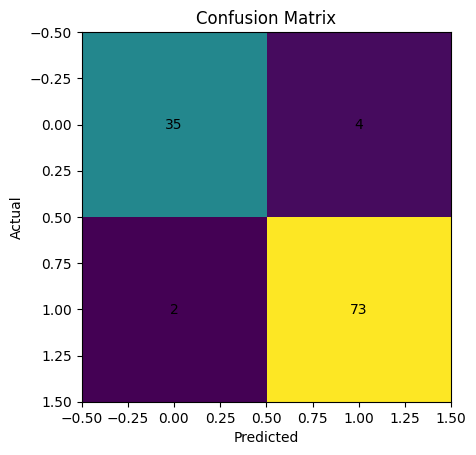

Precision: 0.948051948051948
Recall: 0.9733333333333334
F1 Score: 0.9605263157894731


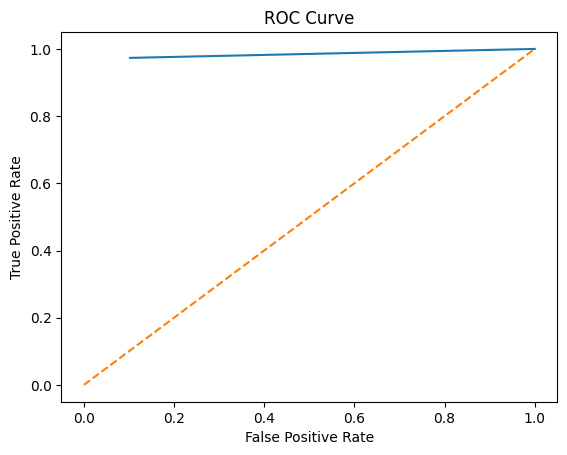

In [32]:
# Predictions
y_probs = model.predict_proba(X_test)
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(cm)

# Metrics
precision, recall, f1 = classification_metrics(y_test, y_pred)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# ROC + AUC
fprs, tprs = roc_curve_manual(y_test, y_probs)
plot_roc(fprs, tprs)

#auc = compute_auc(fprs, tprs)
#print("AUC:", auc)